In [1]:
import warnings
from typing import *

import matplotlib.pyplot as plt
import pandas as pd

from backtest.utils.build_dataset import create_dataset
from backtest.utils.evaluation import (
    compute_equity_curves,
    compute_portfolio_statistics,
    evaluate_experiments_classification,
    evaluate_experiments_topk,
    evaluate_experiments_topk_percent,
    evaluate_experiments_topk_percent_curves,
    get_equity_curve_for_experiment,
    highlight_max,
    random_topk_baseline,
)
from backtest.utils.graphs import (
    plot_bootstrap_ci,
    plot_classification_metrics,
    plot_equity_curves,
    plot_feature_distributions,
    plot_impact_regression,
    plot_pnl_sensitivity,
    plot_robustness_distribution,
    plot_topk_accuracy,
    plot_topk_percent_curves,
)
from backtest.utils.preprocessing import cross_section_standardize
from core.feature_type import FeatureType
from features.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset: 100%|██████████| 498/498 [00:06<00:00, 75.52it/s]
2026-03-26 13:52:54,273 | WARNING | root | No data present for 25 pumps


<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

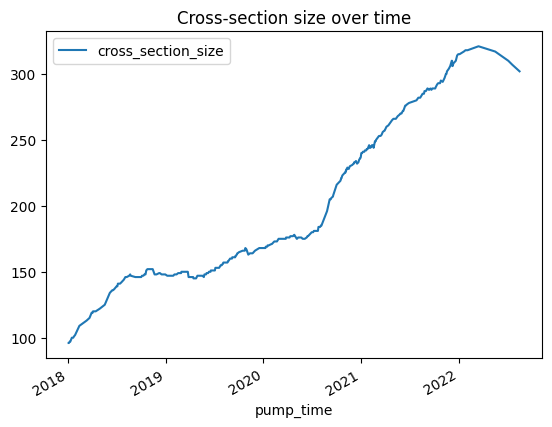

In [3]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and preprocessing</h4>

<p>Inspect feature statistics, clip/fill missing values, and verify no NaNs remain.</p>

In [4]:
# Define feature column groups
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)

all_feature_cols = (
        powerlaw_cols + asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols
        + share_of_long_trades_cols + slippage_imbalance_cols + flow_imbalance_cols + num_trades_cols
)

# Clip powerlaw features to valid range and fill NaNs
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2).fillna(-1)

# Summary statistics
print(f"Dataset shape: {df.shape}")
print(f"NaN rows remaining: {df[all_feature_cols].isna().any(axis=1).sum()}")
df[all_feature_cols].describe().T[["mean", "std", "min", "max"]]

Dataset shape: (93058, 91)
NaN rows remaining: 48484


,mean,std,min,max
powerlaw_alpha@5MIN,1.263149,0.828647,-1.0,2.0
powerlaw_alpha@15MIN,1.329985,0.461583,-1.0,2.0
powerlaw_alpha@1H,1.261707,0.257130,-1.0,2.0
powerlaw_alpha@2H,1.231099,0.236061,-1.0,2.0
powerlaw_alpha@4H,1.208620,0.226379,-1.0,2.0
...,...,...,...,...
num_trades@12H,4307.020514,10927.010818,0.0,437471.0
num_trades@1D,8453.650895,21268.812450,0.0,855882.0
num_trades@2D,16945.006125,41277.808049,0.0,1302688.0
num_trades@7D,59441.423789,135038.076218,0.0,3823480.0


<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [5]:
# Apply cross-sectional standardisation
cols_to_scale: List[str] = asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols
df_scaled: pd.DataFrame = cross_section_standardize(df, cols_to_scale=cols_to_scale)
df_scaled.head(2)

Cross-section standardisation: 473it [00:03, 131.32it/s]


,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped,pump_id
0,-0.444505,0.262494,-0.011331,0.00,0.786943,-1.0,-1.000000,12,-0.261520,0.262494,...,92.02454,92.02454,97.137014,97.137014,ACM-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,True,0
1,1.452517,-0.231829,-0.369049,0.75,0.260517,1.0,0.967997,4,0.095459,-0.231829,...,NaN,NaN,0.000000,-41.666667,TLM-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0


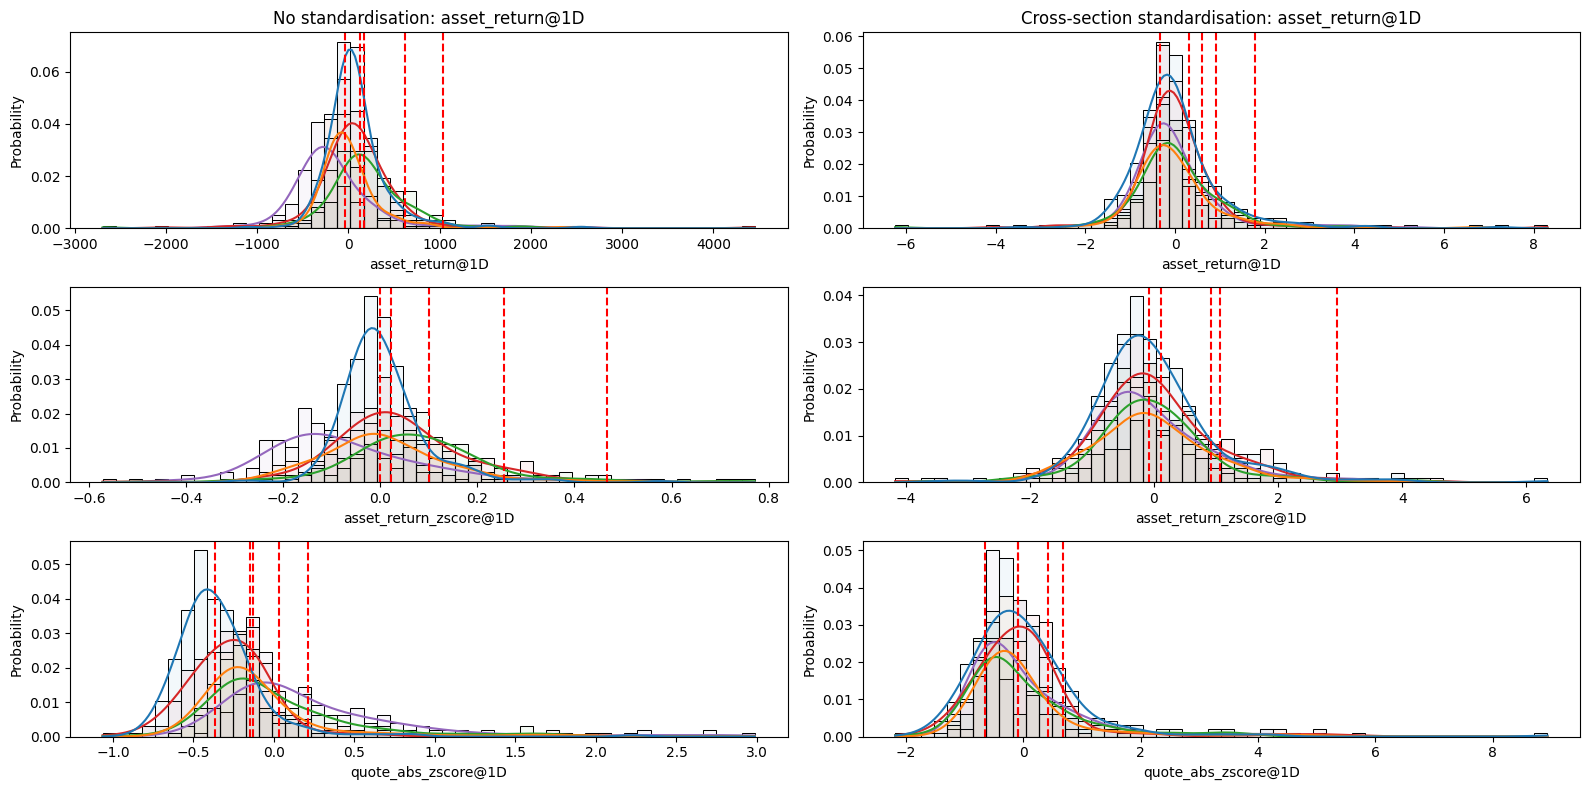

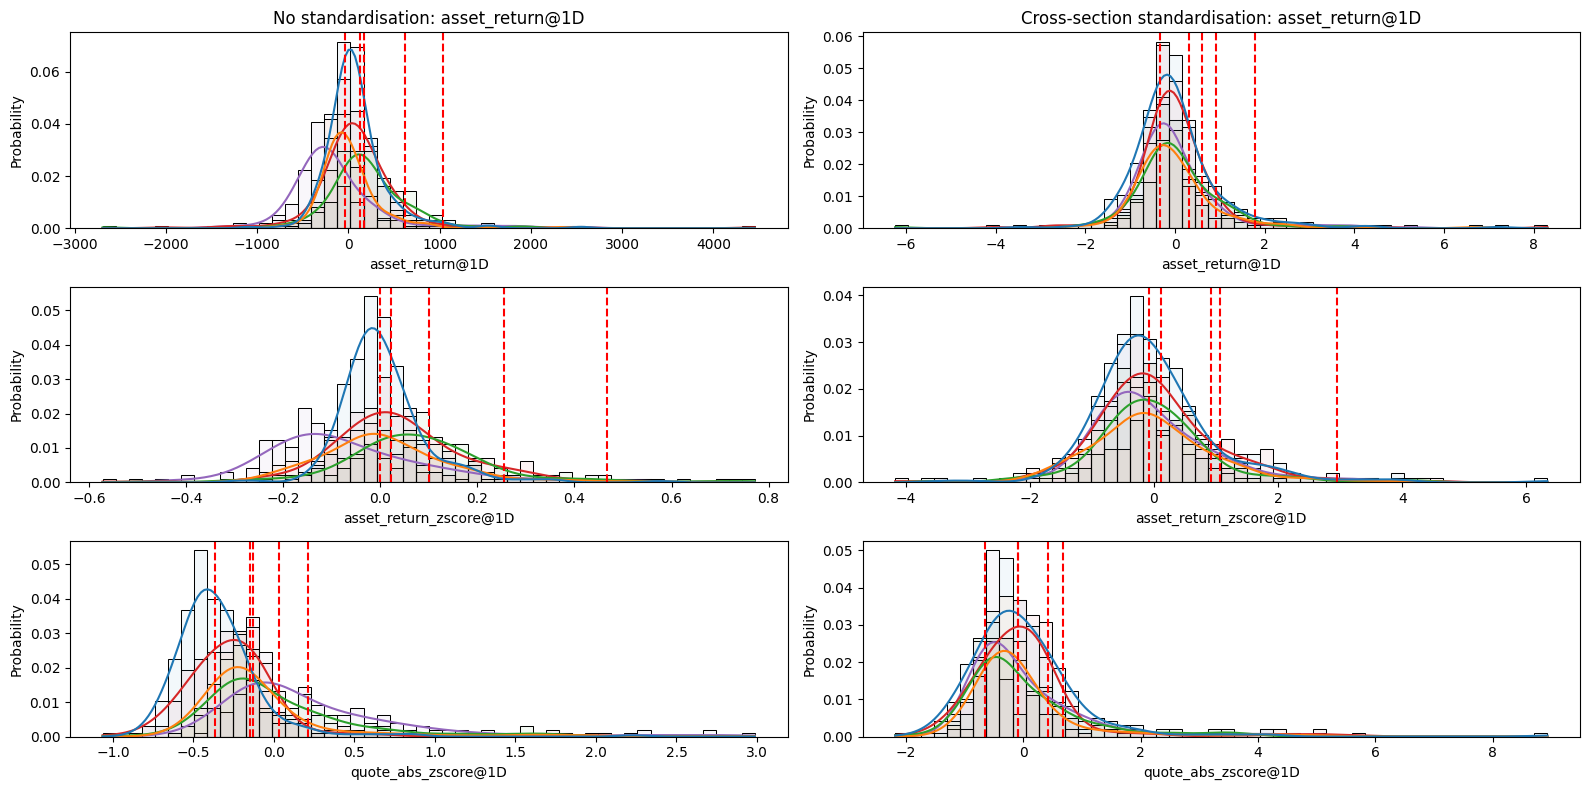

In [6]:
from core.time_utils import NamedTimeDelta

plot_feature_distributions(
    df_raw=df,
    df_scaled=df_scaled,
    feature_types=[FeatureType.ASSET_RETURN, FeatureType.ASSET_RETURN_ZSCORE, FeatureType.QUOTE_ABS_ZSCORE],
    offset=NamedTimeDelta.ONE_DAY,
    n_pumps=5,
    save_path="images/cs_standardization_impact.png",
)

<h4>Split data and train the first model</h4>

In [7]:
from backtest.utils.sample import Sample
from backtest.utils.feature_set import FeatureSet
from backtest.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>LogisticRegression model</h4>

In [8]:
from backtest.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from backtest.pipelines.LogisticRegression.model import LogisticRegressionModel

pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="LogisticRegression", model=model, sample=sample)

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="LogisticRegression + Tuned", model=model, sample=sample)

2026-03-26 13:53:00,682 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:53:00,682 | INFO | root | Building raw dataset from feature files
Building dataset: 100%|██████████| 498/498 [00:05<00:00, 84.18it/s] 
2026-03-26 13:53:07,159 | WARNING | root | No data present for 25 pumps
2026-03-26 13:53:07,210 | INFO | root | Removing failed pump cross sections
2026-03-26 13:53:07,247 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:53:07,614 | INFO | root | Nans
num_trades@5MIN            0
num_trades@15MIN           0
num_trades@1H              0
num_trades@2H              0
num_trades@4H              0
                          ..
asset_return_zscore@1D     0
asset_return_zscore@2D     0
asset_return_zscore@7D     0
asset_return_zscore@14D    0
num_prev_pump              0
Length: 81, dtype: int64
2026-03-26 13:53:07,912 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-26 13:53:07,913 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17

<h4>RandomForestClassifier</h4>

In [9]:
from backtest.pipelines.RandomForest.pipe import RandomForestPipeline
from backtest.pipelines.RandomForest.model import RandomForestModel

pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="RandomForestClassifier", model=model, sample=sample)

model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="RandomForestClassifier + Tuned", model=model, sample=sample)

2026-03-26 13:53:11,941 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:53:11,941 | INFO | root | Using cached raw dataset
2026-03-26 13:53:11,973 | INFO | root | Removing failed pump cross sections
2026-03-26 13:53:12,012 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:53:12,359 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-26 13:53:12,360 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-26 13:53:12,360 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
2026-03-26 13:53:12,394 | INFO | root | Training model
2026-03-26 13:53:13,926 | INFO | root | Training model


<h4>CatboostClassifier</h4>

In [10]:
from backtest.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from backtest.pipelines.CatboostClassifier.model import CatboostClassifierModel

pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatboostClassifier", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatboostClassifier + Tuned", model=model, sample=sample)

2026-03-26 13:53:32,430 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:53:32,430 | INFO | root | Using cached raw dataset
2026-03-26 13:53:32,467 | INFO | root | Removing failed pump cross sections
2026-03-26 13:53:32,508 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:53:32,875 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-26 13:53:32,875 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-26 13:53:32,876 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)


<h4>CatboostClassifier + SMOTE</h4>

In [11]:
from backtest.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatboostClassifier + SMOTE", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatboostClassifier + SMOTE + Tuned", model=model, sample=sample)

2026-03-26 13:53:34,550 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:53:34,551 | INFO | root | Using cached raw dataset
2026-03-26 13:53:34,584 | INFO | root | Removing failed pump cross sections
2026-03-26 13:53:34,626 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:53:35,381 | INFO | root | Nans
num_trades@5MIN            0
num_trades@15MIN           0
num_trades@1H              0
num_trades@2H              0
num_trades@4H              0
                          ..
asset_return_zscore@1D     0
asset_return_zscore@2D     0
asset_return_zscore@7D     0
asset_return_zscore@14D    0
num_prev_pump              0
Length: 81, dtype: int64
2026-03-26 13:53:35,401 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-26 13:53:35,402 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-26 13:53:35,402 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
2026-03-26 13:53:35,440 | INFO | root | Applying SMOTE


<h4>CatboostRanker</h4>

In [12]:
from backtest.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from backtest.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatboostRanker", model=model, sample=sample)

model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatboostRanker + Tuned", model=model, sample=sample)

2026-03-26 13:54:01,004 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:54:01,004 | INFO | root | Using cached raw dataset
2026-03-26 13:54:01,036 | INFO | root | Removing failed pump cross sections
2026-03-26 13:54:01,082 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:54:01,472 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 93)
2026-03-26 13:54:01,472 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 93)
2026-03-26 13:54:01,473 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 93)
2026-03-26 13:54:02,917 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatboostClassifier + TOPKAUC Early stopping</h4>

In [13]:
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkauc_tuned = Experiment(experiment_name="CatboostClassifier + TOPKAUC Early Stopping", model=model,
                                         sample=sample)

2026-03-26 13:54:03,995 | INFO | root | Building dataset and preprocessing data
2026-03-26 13:54:03,996 | INFO | root | Using cached raw dataset
2026-03-26 13:54:04,040 | INFO | root | Removing failed pump cross sections
2026-03-26 13:54:04,090 | WARNING | root | Removed 114 failed pumps
2026-03-26 13:54:04,465 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-26 13:54:04,465 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-26 13:54:04,466 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7553965	test: 0.8318919	best: 0.8318919 (0)	total: 94.2ms	remaining: 1m 34s
10:	learn: 0.8625771	test: 0.8929054	best: 0.8929054 (10)	total: 1.19s	remaining: 1m 46s
20:	learn: 0.8862775	test: 0.8979730	best: 0.8990541 (18)	total: 2.25s	remaining: 1m 44s
30:	learn: 0.8939648	test: 0.9010811	best: 0.9014189 (23)	total: 3.41s	remaining: 1m 46s
40:	learn: 0.9054626	test: 0.9031757	best: 0.9039189 (37)	total: 4.37s	remaining: 1m 42s
50:	learn: 0.9112335	test: 0.9077703	best: 0.9077703 (50)	total: 5.41s	remaining: 1m 40s
60:	learn: 0.9150000	test: 0.9095946	best: 0.9104054 (57)	total: 6.57s	remaining: 1m 41s
70:	learn: 0.9192070	test: 0.9104054	best: 0.9104054 (57)	total: 7.68s	remaining: 1m 40s
80:	learn: 0.9232819	test: 0.9121622	best: 0.9129730 (79)	total: 8.72s	remaining: 1m 38s
90:	learn: 0.9268943	test: 0.9124324	best: 0.9139865 (89)	total: 9.7s	remaining: 1m 36s
100:	learn: 0.9294934	test: 0.9101351	best: 0.9139865 (89)	total: 10.7s	remaining: 1m 34s
110:	learn: 0.9338106	

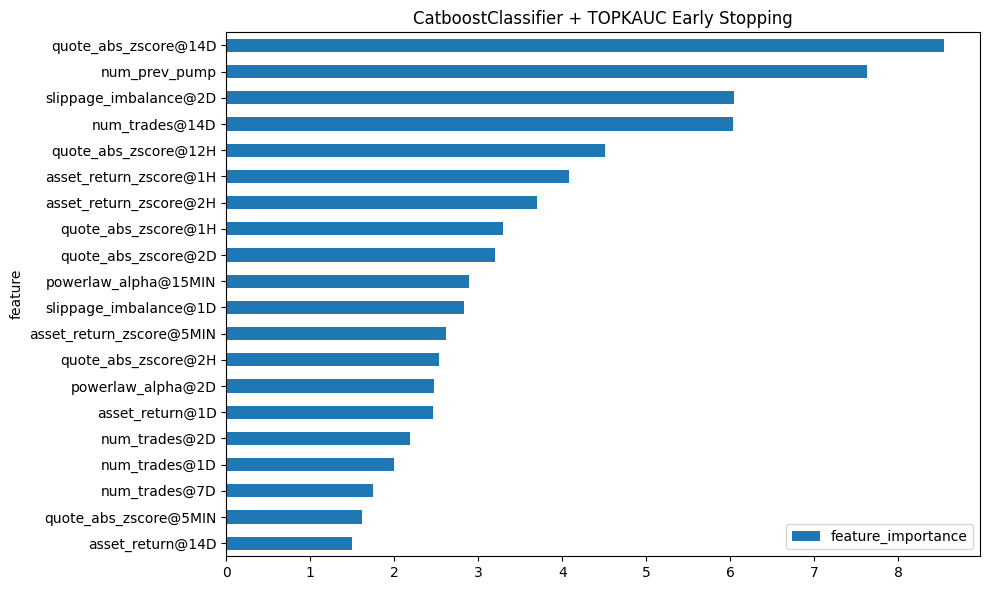

In [14]:
model = experiment_cb_topkauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatboostClassifier + TOPKAUC Early Stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h4>TOPK metric for all models</h4>

In [15]:
from backtest.utils.sample import DatasetType
from backtest.utils.experiment import Experiment

experiments: List[Experiment] = [
    experiment_lr, experiment_lr_tuned,
    experiment_rf, experiment_rf_tuned,
    experiment_cb, experiment_cb_tuned,
    experiment_cb_smote, experiment_cb_smote_tuned,
    experiment_cb_ranker, experiment_cb_ranker_tuned,
    experiment_cb_topkauc_tuned,
]

In [16]:
df_topk = evaluate_experiments_topk(experiments)
styled = df_topk.T.style.apply(highlight_max, axis=0)
styled

Top@K: 100%|██████████| 11/11 [00:01<00:00,  7.21it/s]


,1,2,3,5,10,20,30
LogisticRegression,0.172414,0.206897,0.275862,0.379310,0.500000,0.672414,0.706897
LogisticRegression + Tuned,0.120690,0.172414,0.241379,0.362069,0.534483,0.706897,0.758621
RandomForestClassifier,0.120690,0.206897,0.258621,0.293103,0.362069,0.568966,0.672414
RandomForestClassifier + Tuned,0.137931,0.224138,0.310345,0.344828,0.500000,0.689655,0.775862
CatboostClassifier,0.103448,0.241379,0.275862,0.362069,0.500000,0.637931,0.793103
CatboostClassifier + Tuned,0.155172,0.224138,0.310345,0.362069,0.500000,0.689655,0.775862
CatboostClassifier + SMOTE,0.051724,0.155172,0.206897,0.224138,0.344828,0.431034,0.568966
CatboostClassifier + SMOTE + Tuned,0.051724,0.155172,0.206897,0.275862,0.396552,0.534483,0.603448
CatboostRanker,0.103448,0.206897,0.275862,0.327586,0.431034,0.517241,0.603448
CatboostRanker + Tuned,0.068966,0.120690,0.241379,0.310345,0.431034,0.568966,0.637931


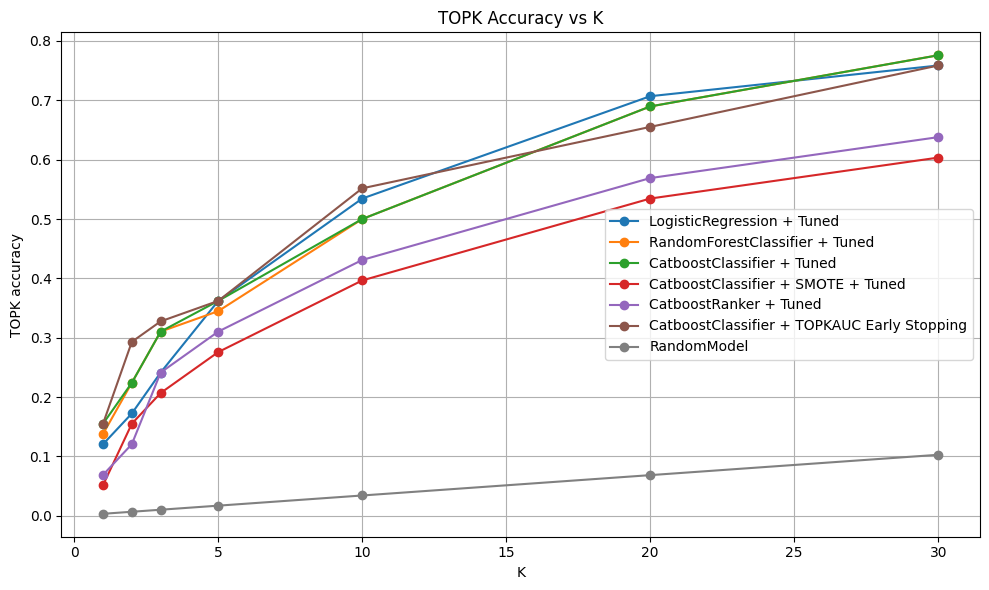

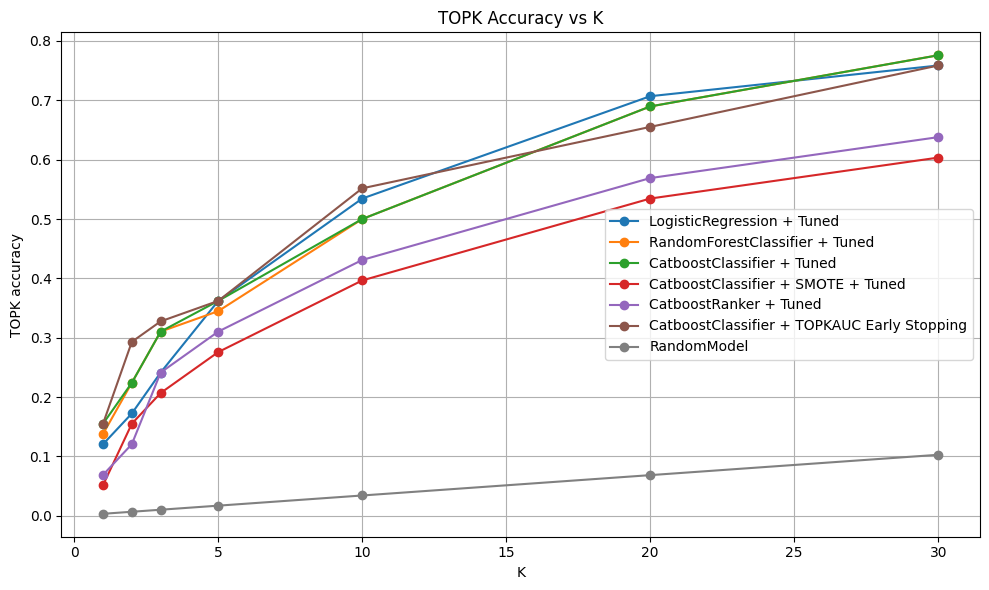

In [17]:
cols = [col for col in df_topk.columns if col.endswith("Tuned")] + ["CatboostClassifier + TOPKAUC Early Stopping"]
sample = experiment_cb_topkauc_tuned.get_sample()
baseline = random_topk_baseline(sample.get_dataset(DatasetType.TEST))

plot_topk_accuracy(df_topk, cols=cols, random_baseline=baseline, save_path="images/topk_accuracy_test.png")

<h4>TOPK% for models</h4>

In [18]:
df_topkp = evaluate_experiments_topk_percent(experiments)
styled = df_topkp.style.apply(highlight_max, axis=1)
styled

Top@K%: 100%|██████████| 11/11 [00:01<00:00,  8.80it/s]


,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.010000,0.275862,0.275862,0.258621,0.310345,0.275862,0.310345,0.206897,0.241379,0.275862,0.275862,0.327586
0.020000,0.396552,0.396552,0.310345,0.379310,0.379310,0.431034,0.224138,0.327586,0.362069,0.396552,0.431034
0.050000,0.568966,0.603448,0.448276,0.586207,0.517241,0.620690,0.379310,0.448276,0.517241,0.482759,0.586207
0.100000,0.706897,0.758621,0.672414,0.775862,0.775862,0.758621,0.568966,0.603448,0.603448,0.637931,0.775862
0.200000,0.827586,0.862069,0.810345,0.913793,0.862069,0.862069,0.706897,0.741379,0.724138,0.758621,0.844828
0.500000,0.965517,0.965517,0.931034,0.982759,0.965517,0.982759,0.931034,0.965517,0.844828,0.844828,0.982759


<h4>TOPK% curves for all models</h4>

Top@K% curves: 100%|██████████| 11/11 [00:12<00:00,  1.13s/it]


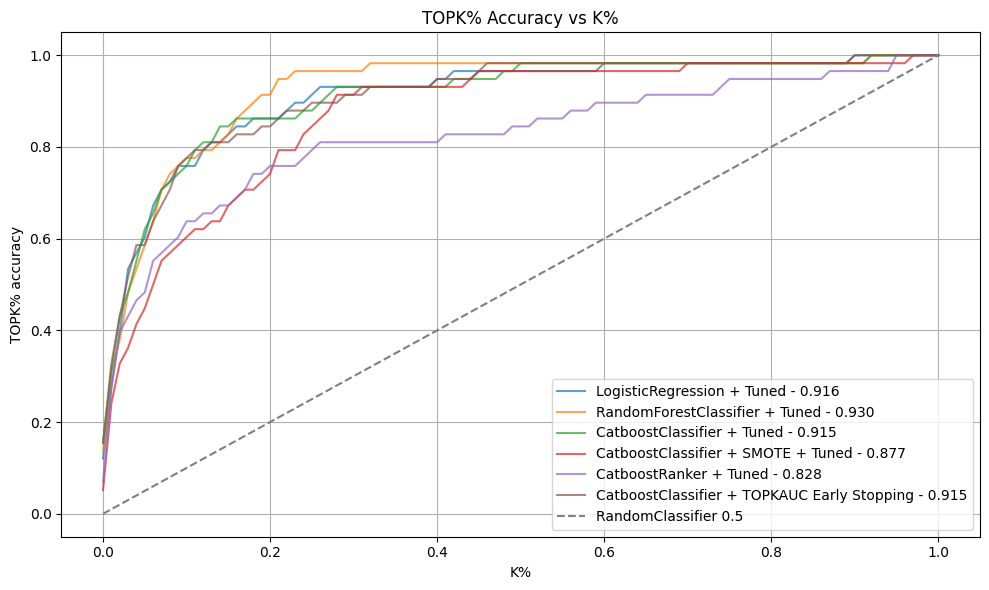

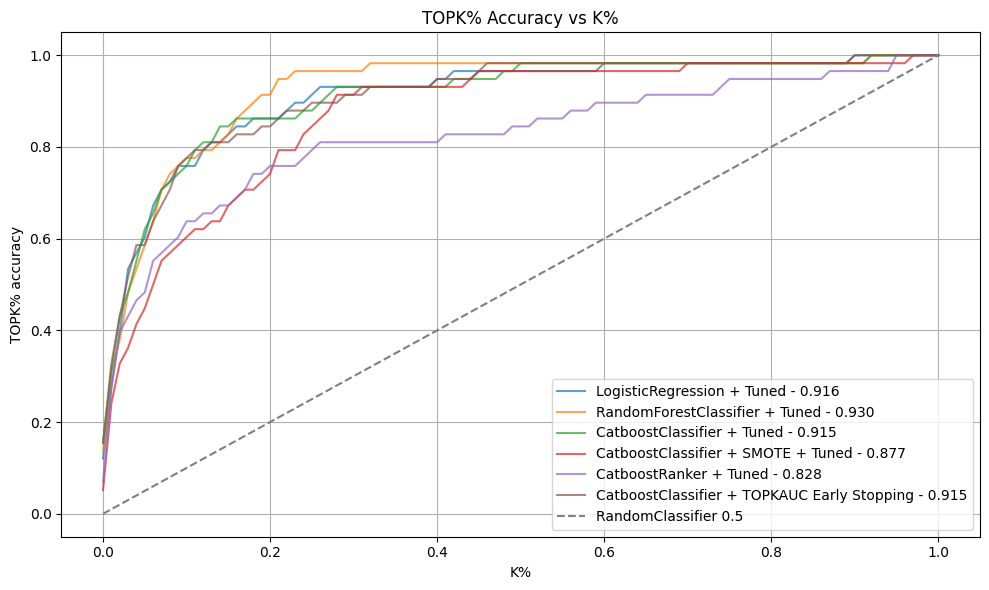

In [19]:
df_topkp_curves, auc_scores = evaluate_experiments_topk_percent_curves(experiments)
plot_topk_percent_curves(df_topkp_curves, cols=cols, auc_scores=auc_scores, save_path="images/topkp_auc_test.png")

<h4>Classification metrics on TEST</h4>
<p>Alongside ranking metrics, we also report PR-AUC, F1, and balanced accuracy. For F1/balanced accuracy we use the <code>top1_per_cross_section</code> decision rule.</p>

In [20]:
df_classification_metrics = evaluate_experiments_classification(experiments)
styled = df_classification_metrics.style.apply(highlight_max, axis=0).format("{:.4f}")
styled

Classification metrics: 100%|██████████| 11/11 [00:02<00:00,  4.20it/s]


,PR-AUC,F1 (top1/cross-section),Balanced Accuracy (top1/cross-section)
Model,,,
LogisticRegression,0.0868,0.1724,0.5848
LogisticRegression + Tuned,0.0611,0.1207,0.5588
RandomForestClassifier,0.1017,0.1207,0.5588
RandomForestClassifier + Tuned,0.0681,0.1379,0.5675
CatboostClassifier,0.1000,0.1034,0.5502
CatboostClassifier + Tuned,0.1002,0.1552,0.5761
CatboostClassifier + SMOTE,0.0351,0.0517,0.5242
CatboostClassifier + SMOTE + Tuned,0.0532,0.0517,0.5242
CatboostRanker,0.0439,0.1034,0.5502


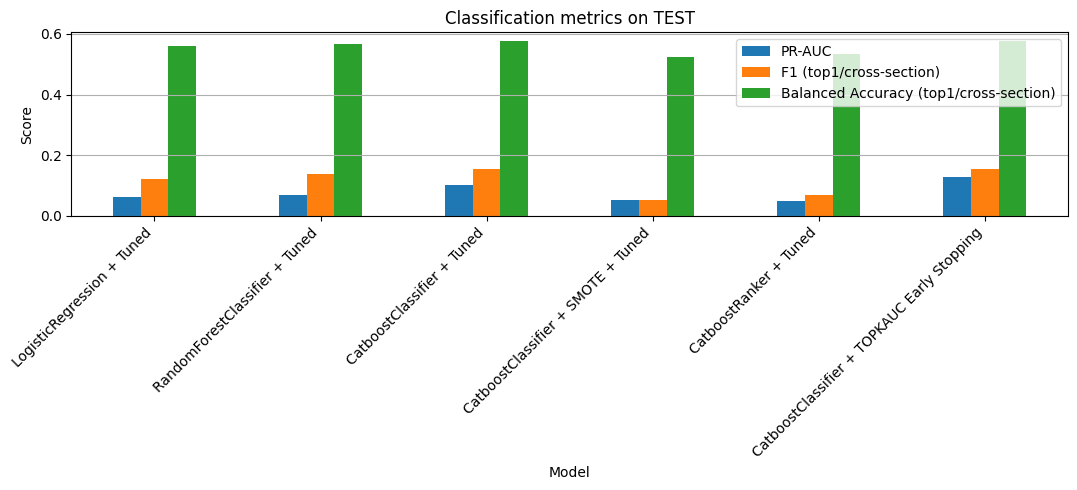

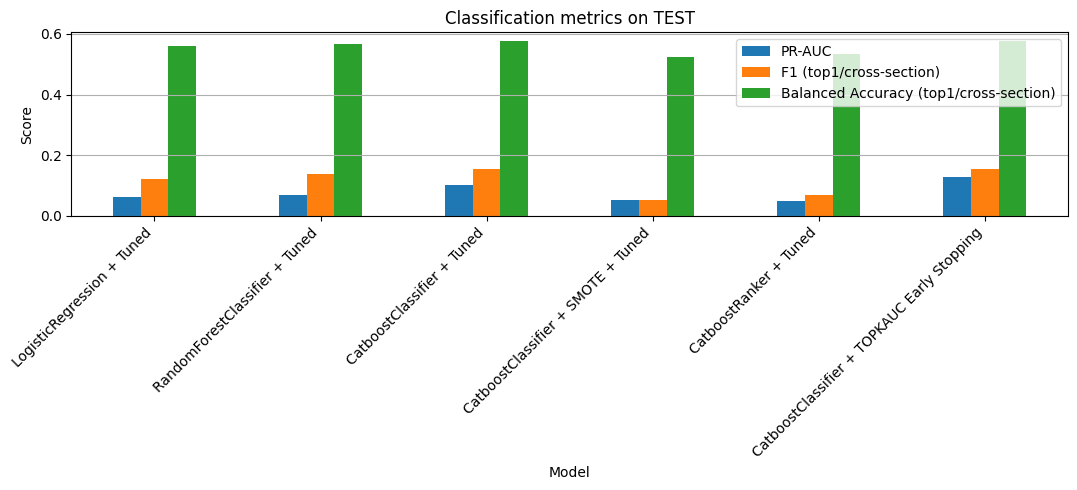

In [21]:
plot_classification_metrics(df_classification_metrics, cols=cols, save_path="images/classification_metrics_test.png")

<h4>Test Sample PnL</h4>

In [22]:
df_curves = compute_equity_curves(experiments)

Equity curve: LogisticRegression K=5:  98%|█████████▊| 57/58 [00:15<00:00,  8.50it/s]2026-03-26 13:54:58,919 | INFO | root | No data to get prices for BRD-BTC
2026-03-26 13:54:58,968 | INFO | root | No data to get prices for NXS-BTC
Equity curve: LogisticRegression + Tuned K=5:  88%|████████▊ | 51/58 [00:15<00:00,  8.47it/s]2026-03-26 13:55:14,294 | INFO | root | No data to get prices for EVX-BTC
2026-03-26 13:55:14,311 | INFO | root | No data to get prices for RDN-BTC
Equity curve: LogisticRegression + Tuned K=5:  97%|█████████▋| 56/58 [00:15<00:00,  9.24it/s]2026-03-26 13:55:14,841 | INFO | root | No data to get prices for BRD-BTC
2026-03-26 13:55:14,852 | INFO | root | No data to get prices for NXS-BTC
2026-03-26 13:55:14,901 | INFO | root | No data to get prices for NAV-BTC
Equity curve: CatboostClassifier + SMOTE K=5: 100%|██████████| 58/58 [00:15<00:00,  3.72it/s]
Equity curve: CatboostClassifier + SMOTE + Tuned K=5: 100%|██████████| 58/58 [00:16<00:00,  3.58it/s]
Equity curve: C

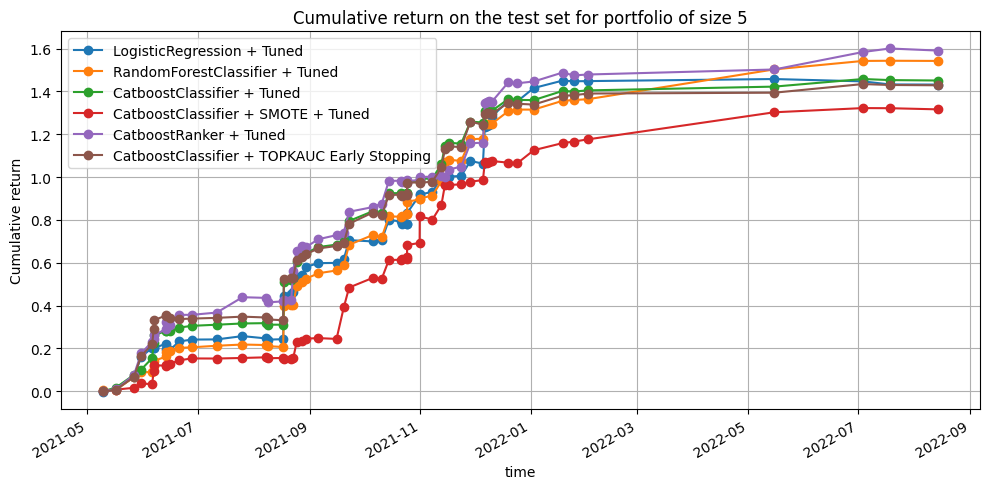

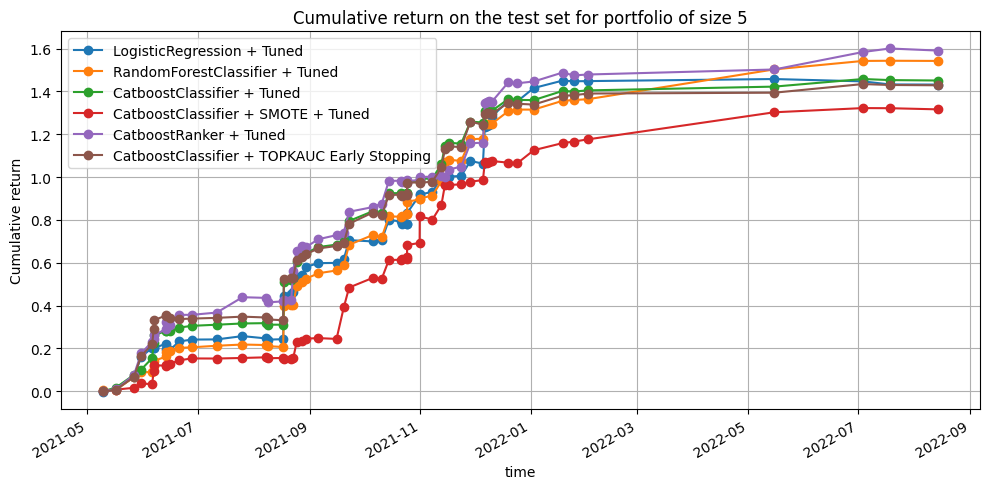

In [23]:
plot_equity_curves(df_curves, cols=cols, save_path="images/portfolios_test.png")

<h4>Portfolio performance for TOPKAUC ES Model</h4>

In [24]:
curves: Dict[int, pd.Series] = {}
for k in [1, 2, 5, 10, 20, 30]:
    curves[k] = get_equity_curve_for_experiment(experiment=experiment_cb_topkauc_tuned, portfolio_size=k)

Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=1: 100%|██████████| 58/58 [00:11<00:00,  5.19it/s]
Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=2: 100%|██████████| 58/58 [00:14<00:00,  4.07it/s]
Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=5: 100%|██████████| 58/58 [00:18<00:00,  3.16it/s]
Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=10: 100%|██████████| 58/58 [00:28<00:00,  2.04it/s]
Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=20: 100%|██████████| 58/58 [00:47<00:00,  1.23it/s]
Equity curve: CatboostClassifier + TOPKAUC Early Stopping K=30: 100%|██████████| 58/58 [01:05<00:00,  1.14s/it]


In [25]:
df = pd.concat(curves, axis=1)
df.columns = [1, 2, 5, 10, 20, 30]

df_results = compute_portfolio_statistics(df)
df_results

,trading avg return,annualized return,annualized volatility,Sharpe ratio
1,0.079445,3.194108,1.203141,2.654807
2,0.051544,2.072324,0.661880,3.130967
5,0.028012,1.126234,0.317734,3.544583
10,0.021797,0.876353,0.216603,4.045892
20,0.012843,0.516347,0.132485,3.897402
30,0.010279,0.413282,0.111509,3.706249


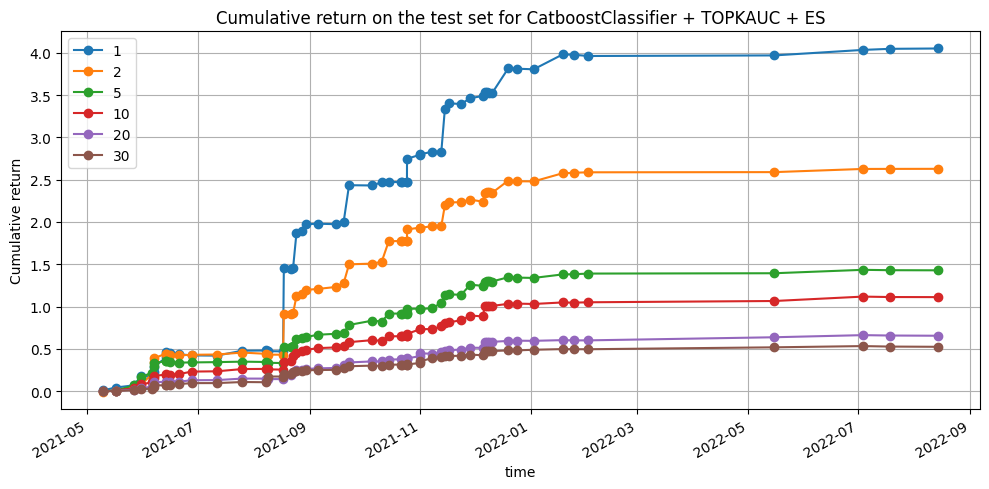

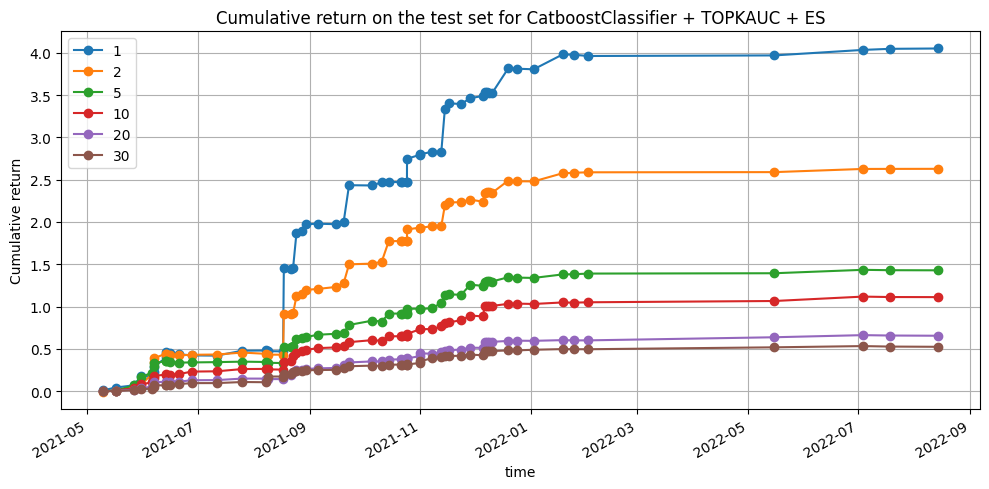

In [26]:
plot_equity_curves(
    df,
    title="Cumulative return on the test set for CatboostClassifier + TOPKAUC + ES",
    save_path="images/portfolios_test.png",
)

<h4>Execution-aware PnL with trade-based price impact</h4>
<p>We fit a side-aware price impact model for each traded asset using the previous 14 days of trade-level data. Trades sharing the same execution timestamp are aggregated into meta-orders, binned by notional size (log-spaced), and the median impact per bin is used as a non-parametric impact estimate. Strategy PnL is then recomputed for different intended order sizes.</p>


In [27]:
from datetime import timedelta
from backtest.portfolio.TOPKPortfolio import evaluate_topk_pnl_for_quantities

impact_quantities_usdt = [100, 200, 500, 1000, 2000, 5000, 10000]

dataset_test = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST)

df_pnl_by_quantity = evaluate_topk_pnl_for_quantities(
    model=experiment_cb_topkauc_tuned.get_model(),
    dataset=dataset_test,
    portfolio_size=5,
    quantities_usdt=impact_quantities_usdt,
    buy_before=timedelta(minutes=60),
    sell_after=timedelta(minutes=1),
    impact_lookback_days=14,
    impact_liquidity_quantile=0.9,
)

df_pnl_by_quantity["mean_roe_pct"] = 100.0 * df_pnl_by_quantity["mean_roe"]
df_pnl_by_quantity[["quantity_usdt", "mean_roe_pct"]]

,quantity_usdt,mean_roe_pct
0,100.0,3.242367
1,200.0,3.213653
2,500.0,3.128151
3,1000.0,2.963315
4,2000.0,2.256504
5,5000.0,0.951864
6,10000.0,0.475932


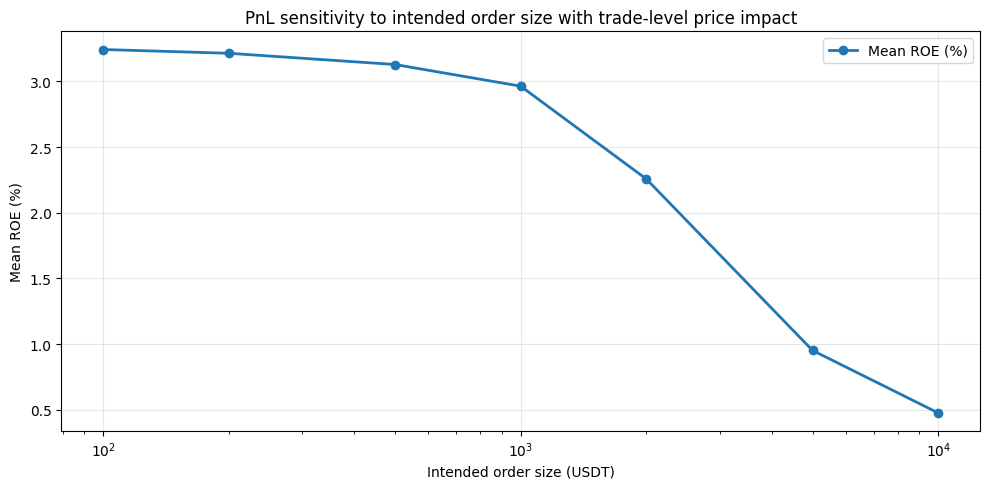

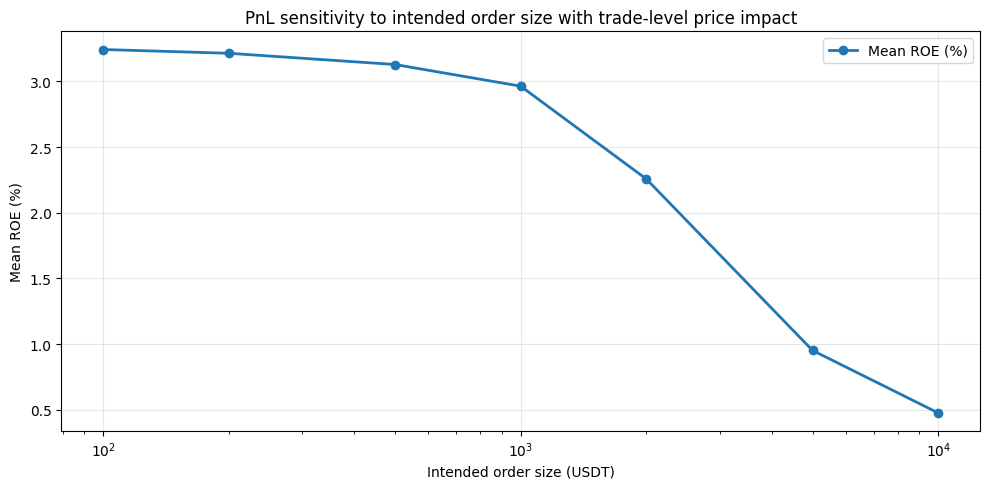

In [28]:
df_pnl_by_quantity["mean_roe_pct"] = 100.0 * df_pnl_by_quantity["mean_roe"]
plot_pnl_sensitivity(df_pnl_by_quantity, save_path="images/pnl_vs_quantity_with_impact.png")

<h5>Example: fitted sqrt impact model for one pump asset</h5>
<p>Pick one pump asset with sufficient trade history (14-day lookback), aggregate fills by execution time into meta-orders, classify each as buy- or sell-initiated, convert notionals to USDT, and fit: I(Q) = max(0, a + β√Q_usdt) via constrained OLS (β ≥ 0, a unconstrained). Fitting in USDT space ensures the impact curve is comparable across BTC price regimes. A negative intercept creates a dead zone where small orders have zero impact.</p>
<pre>side(order) = +1 if net buy-initiated notional > 0, else -1</pre>
<pre>impact_bps(order) = max(0, side × (price_last / price_first - 1) × 10000)</pre>

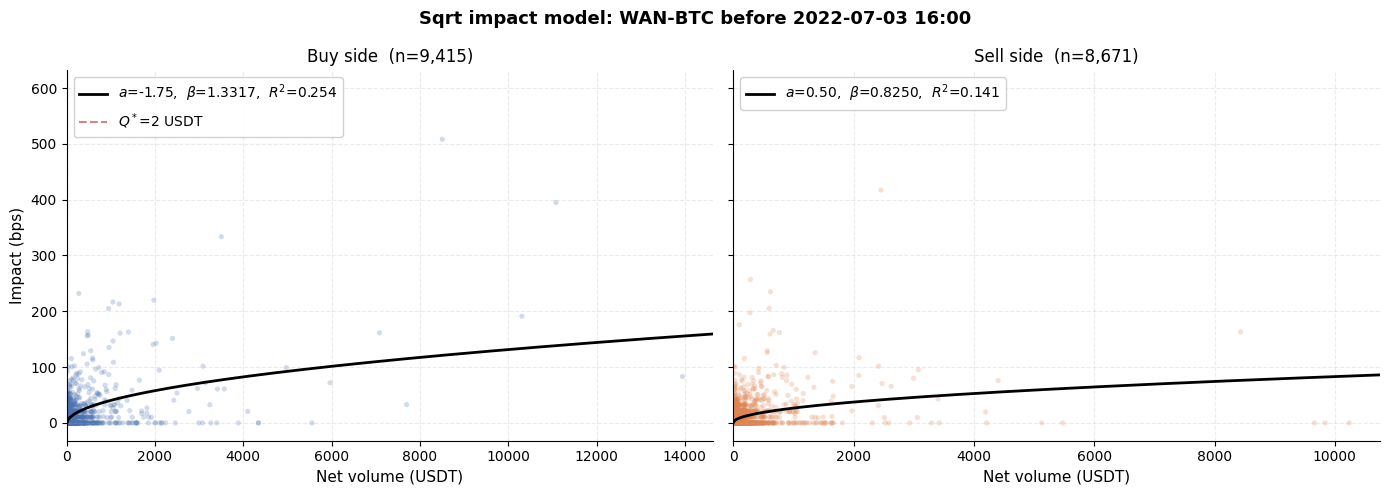

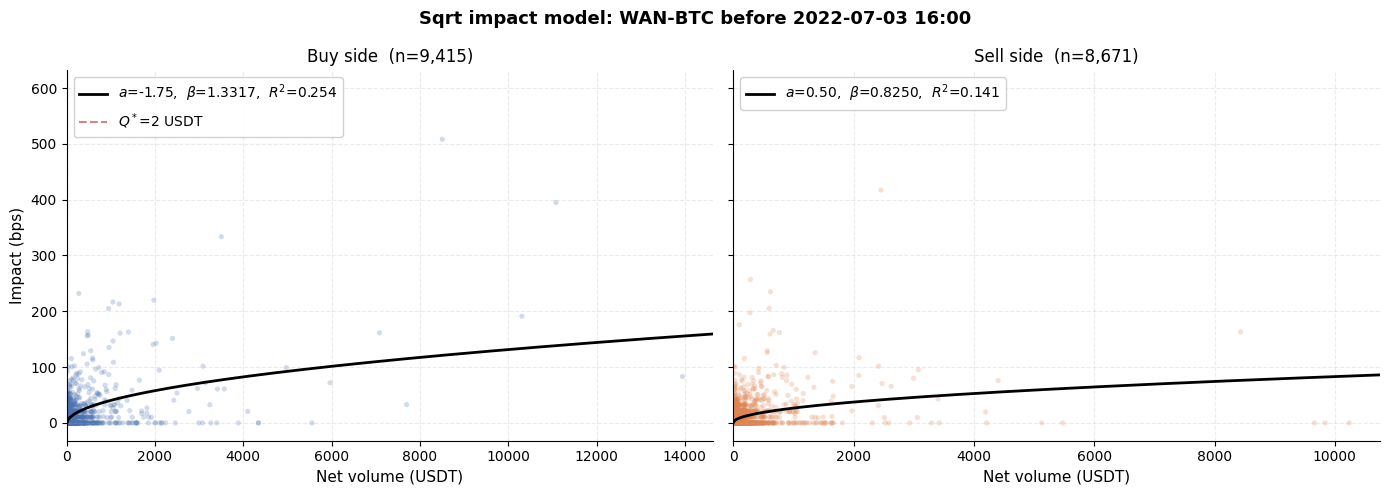

In [29]:
from backtest.utils.impact_example import find_best_impact_example

dataset_test = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST)
example = find_best_impact_example(dataset_test)

samples = example.fit_result.samples[example.fit_result.samples["notional_usdt"] > 0].copy()
plot_impact_regression(
    model=example.fit_result.model,
    samples=samples,
    currency_pair_name=example.currency_pair.name,
    pump_time=example.pump.time,
    save_path="images/impact_regression_example.png",
)

<h4>Robustness checks: train on subset of cross-sections</h4>
<p>We repeatedly train the same pipeline on random subsets of <code>TRAIN</code> cross-sections, evaluate on the fixed <code>TEST</code> split, and collect a distribution of ranking metrics.</p>

In [30]:
from pathlib import Path
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline
from backtest.robust.robustness import run_cross_section_subset_robustness, summarise_robustness_distribution

ROBUSTNESS_OUTPUT: Path = Path("analysis_outputs/robustness/catboost_topkauc_subset_runs.csv")

df_robustness: pd.DataFrame = run_cross_section_subset_robustness(
    pipeline_factory=CatboostClassifierTOPKAUCPipeline,
    subset_fraction=0.7,
    n_runs=25,
    tuned=True,
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
    base_seed=42,
    output_path=ROBUSTNESS_OUTPUT,
)

df_robustness.head()

2026-03-26 14:02:45,922 | INFO | root | Using cached preprocessed datasets for CatboostClassifierTOPKAUCPipeline
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7568239	test: 0.8295946	best: 0.8295946 (0)	total: 91.5ms	remaining: 1m 31s
10:	learn: 0.8821698	test: 0.8920270	best: 0.8970946 (8)	total: 1.02s	remaining: 1m 32s
20:	learn: 0.9016038	test: 0.8993243	best: 0.9014865 (18)	total: 1.92s	remaining: 1m 29s
30:	learn: 0.9122956	test: 0.9087162	best: 0.9087162 (30)	total: 2.81s	remaining: 1m 27s
40:	learn: 0.9200943	test: 0.9095946	best: 0.9100676 (34)	total: 3.81s	remaining: 1m 29s
50:	learn: 0.9257862	test: 0.9106757	best: 0.9114189 (48)	total: 4.78s	remaining: 1m 28s
60:	learn: 0.9284277	test: 0.9147297	best: 0.9147297 (60)	total: 5.7s	remaining: 1m 27s
70:	learn: 0.9337421	test: 0.9195946	best: 0.9195946 (70)	total: 6.68s	remaining: 1m 27s
80:	learn: 0.9377358	test: 0.9159459	best: 0.9195946 (71)	total: 7.68s	remaining: 1m 27s
90:	learn: 0.9416038	test: 0.9122973	best: 0.9195946 (71)	total: 8.9s	remaining: 1m 28s
100:	learn: 0.9474214	test: 0.9131757	best: 0.9195946 (71)	total: 9.79s	remaining: 1m 27s
110:	learn: 0.9501887	te

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7658176	test: 0.8304054	best: 0.8304054 (0)	total: 107ms	remaining: 1m 46s
10:	learn: 0.8705975	test: 0.8929730	best: 0.8974324 (8)	total: 1.02s	remaining: 1m 31s
20:	learn: 0.8929560	test: 0.9037838	best: 0.9037838 (20)	total: 1.89s	remaining: 1m 28s
30:	learn: 0.9065409	test: 0.9076351	best: 0.9097297 (29)	total: 2.84s	remaining: 1m 28s
40:	learn: 0.9136164	test: 0.9061486	best: 0.9110135 (34)	total: 3.85s	remaining: 1m 30s
50:	learn: 0.9211321	test: 0.9090541	best: 0.9110135 (34)	total: 4.81s	remaining: 1m 29s
60:	learn: 0.9253774	test: 0.9077703	best: 0.9110135 (34)	total: 5.83s	remaining: 1m 29s
70:	learn: 0.9301572	test: 0.9068243	best: 0.9110135 (34)	total: 6.86s	remaining: 1m 29s
80:	learn: 0.9336792	test: 0.8977703	best: 0.9110135 (34)	total: 7.76s	remaining: 1m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9110135135
bestIteration = 34

Shrink model to first 35 iterations.


/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


...

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7529560	test: 0.8304054	best: 0.8304054 (0)	total: 95.8ms	remaining: 1m 35s
10:	learn: 0.8634277	test: 0.8945270	best: 0.8962162 (9)	total: 1.02s	remaining: 1m 31s
20:	learn: 0.8826730	test: 0.9036486	best: 0.9040541 (19)	total: 2.03s	remaining: 1m 34s
30:	learn: 0.8964151	test: 0.9077703	best: 0.9077703 (30)	total: 2.91s	remaining: 1m 30s
40:	learn: 0.9060377	test: 0.9079054	best: 0.9092568 (34)	total: 3.89s	remaining: 1m 31s
50:	learn: 0.9106918	test: 0.9169595	best: 0.9169595 (50)	total: 4.86s	remaining: 1m 30s
60:	learn: 0.9185220	test: 0.9147297	best: 0.9190541 (52)	total: 5.74s	remaining: 1m 28s
70:	learn: 0.9234591	test: 0.9139189	best: 0.9190541 (52)	total: 6.58s	remaining: 1m 26s
80:	learn: 0.9282075	test: 0.9146622	best: 0.9190541 (52)	total: 7.43s	remaining: 1m 24s
90:	learn: 0.9320440	test: 0.9137162	best: 0.9190541 (52)	total: 8.35s	remaining: 1m 23s
100:	learn: 0.9355031	test: 0.9133108	best: 0.9190541 (52)	total: 9.23s	remaining: 1m 22s
Stopped by overfitting

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7522956	test: 0.8317568	best: 0.8317568 (0)	total: 78.1ms	remaining: 1m 18s
10:	learn: 0.8662893	test: 0.8855405	best: 0.8967568 (4)	total: 852ms	remaining: 1m 16s
20:	learn: 0.8930503	test: 0.8992568	best: 0.8992568 (20)	total: 1.63s	remaining: 1m 15s
30:	learn: 0.9076730	test: 0.9020270	best: 0.9043243 (26)	total: 2.4s	remaining: 1m 15s
40:	learn: 0.9163208	test: 0.9104054	best: 0.9104054 (40)	total: 3.25s	remaining: 1m 16s
50:	learn: 0.9235535	test: 0.9078378	best: 0.9115541 (41)	total: 4.04s	remaining: 1m 15s
60:	learn: 0.9281761	test: 0.9097973	best: 0.9115541 (41)	total: 4.82s	remaining: 1m 14s
70:	learn: 0.9321384	test: 0.9092568	best: 0.9115541 (41)	total: 5.6s	remaining: 1m 13s
80:	learn: 0.9342767	test: 0.9108784	best: 0.9115541 (41)	total: 6.4s	remaining: 1m 12s
90:	learn: 0.9384906	test: 0.9074324	best: 0.9115541 (41)	total: 7.24s	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9115540541
bestIteration = 41

Shrink model to 

,run_idx,seed,subset_fraction,train_rows,train_cross_sections,test_rows,test_cross_sections,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,0,42,0.7,24668,159,16960,58,0.932112,0.327586,0.465517,0.655172,0.810345,0.913793
1,1,43,0.7,24613,159,16960,58,0.920388,0.275862,0.431034,0.603448,0.758621,0.879310
2,2,44,0.7,24651,159,16960,58,0.925948,0.293103,0.379310,0.568966,0.724138,0.879310
3,3,45,0.7,24876,159,16960,58,0.900948,0.310345,0.431034,0.603448,0.724138,0.810345
4,4,46,0.7,24536,159,16960,58,0.922543,0.293103,0.413793,0.603448,0.810345,0.862069


In [31]:
robustness_summary: pd.DataFrame = summarise_robustness_distribution(
    results=df_robustness,
    metric_cols=[
        "topk_percent_auc",
        "topk_percent@0.01",
        "topk_percent@0.02",
        "topk_percent@0.05",
        "topk_percent@0.1",
        "topk_percent@0.2",
    ],
)

robustness_summary

,count,mean,std,min,10%,25%,50%,75%,90%,max
topk_percent_auc,25.0,0.917391,0.009130,0.900948,0.903509,0.913276,0.920388,0.922543,0.927491,0.932112
topk_percent@0.01,25.0,0.300690,0.039215,0.224138,0.255172,0.275862,0.293103,0.327586,0.355172,0.379310
topk_percent@0.02,25.0,0.432414,0.039480,0.362069,0.368966,0.413793,0.431034,0.465517,0.465517,0.517241
topk_percent@0.05,25.0,0.608276,0.037748,0.534483,0.568966,0.586207,0.603448,0.620690,0.665517,0.689655
topk_percent@0.1,25.0,0.757931,0.039025,0.655172,0.724138,0.741379,0.758621,0.775862,0.810345,0.810345
topk_percent@0.2,25.0,0.873793,0.028032,0.810345,0.844828,0.862069,0.879310,0.896552,0.896552,0.931034


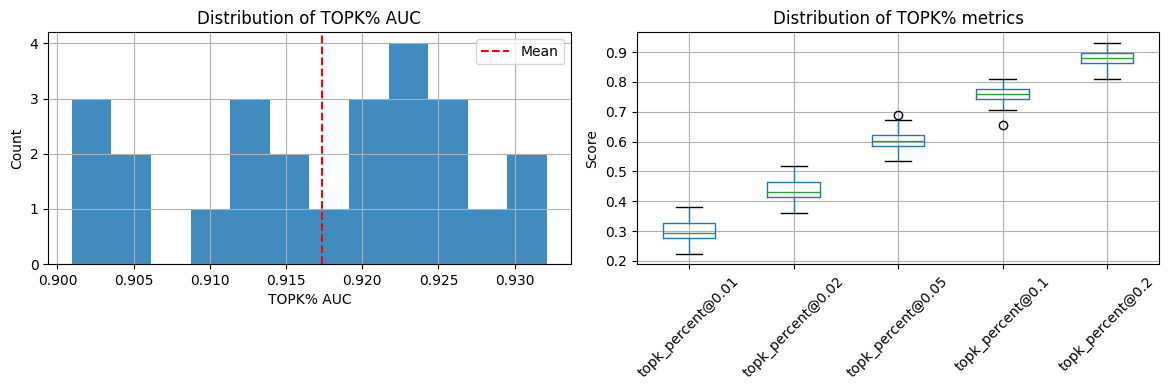

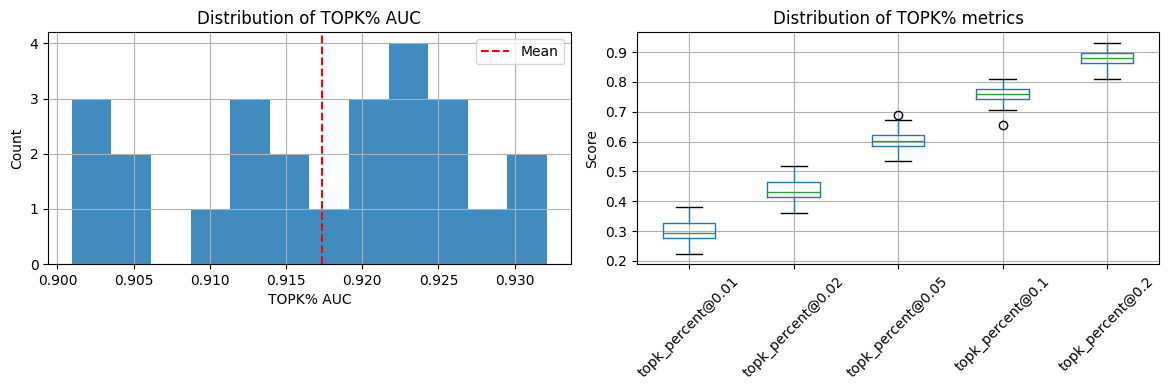

In [32]:
metric_cols = ["topk_percent@0.01", "topk_percent@0.02", "topk_percent@0.05", "topk_percent@0.1", "topk_percent@0.2"]
plot_robustness_distribution(df_robustness, metric_cols=metric_cols,
                             save_path="images/robustness_metrics_distribution.png")

<h4>Temporal robustness: subperiod analysis</h4>
<p>We split the test set into two temporal subperiods (early vs late) and evaluate Top@K% and Top@K%-AUC on each half independently. This checks whether the model generalises across different market regimes within the test window.</p>

In [33]:
from backtest.robust.robustness import evaluate_subperiod_metrics

best_model = experiment_cb_topkauc_tuned.get_model()
test_df = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST).all_data()

df_subperiod = evaluate_subperiod_metrics(
    model=best_model,
    dataset_df=test_df,
    date_col="pump_time",
    split_date="2022-06-01",
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
)

df_subperiod

,subperiod,n_pumps,n_rows,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,early,55,16041,0.914636,0.345455,0.454545,0.581818,0.781818,0.836364
1,late,3,919,0.925833,0.000000,0.000000,0.666667,0.666667,1.000000


<h4>Statistical significance: bootstrap CIs and paired hypothesis test</h4>
<p>Below we quantify uncertainty (95% confidence intervals) and test whether performance differences are statistically meaningful.</p>

In [34]:
from backtest.robust.significance import (
    score_dataset,
    bootstrap_topk_ci,
    bootstrap_topk_percent_ci,
    bootstrap_topk_percent_auc_ci,
    paired_bootstrap_topk_percent_auc_test,
)

exp_a = experiment_cb_topkauc_tuned
exp_b = experiment_cb_tuned

scored_a = score_dataset(
    model=exp_a.get_model(),
    dataset=exp_a.get_sample().get_dataset(DatasetType.TEST),
)
scored_b = score_dataset(
    model=exp_b.get_model(),
    dataset=exp_b.get_sample().get_dataset(DatasetType.TEST),
)

ci_auc_a = bootstrap_topk_percent_auc_ci(scored_df=scored_a, n_bootstrap=1000, alpha=0.05, random_state=42)
ci_auc_b = bootstrap_topk_percent_auc_ci(scored_df=scored_b, n_bootstrap=1000, alpha=0.05, random_state=42)

df_auc_ci = pd.DataFrame([
    {"model": exp_a.get_experiment_name(), **ci_auc_a.to_dict()},
    {"model": exp_b.get_experiment_name(), **ci_auc_b.to_dict()},
]).set_index("model")

df_auc_ci[["point_estimate", "ci_lower", "ci_upper"]]

,point_estimate,ci_lower,ci_upper
model,,,
CatboostClassifier + TOPKAUC Early Stopping,0.915216,0.868683,0.949407
CatboostClassifier + Tuned,0.915474,0.868223,0.950435


In [35]:
topk_bins = [1, 2, 3, 5, 10, 20, 30]
topkp_bins = [0.01, 0.02, 0.05, 0.1, 0.2]

df_topk_ci = bootstrap_topk_ci(
    scored_df=scored_a,
    bins=topk_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topkp_ci = bootstrap_topk_percent_ci(
    scored_df=scored_a,
    bins=topkp_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topk_ci

,point_estimate,mean_bootstrap,std_bootstrap,ci_lower,ci_upper,n_bootstrap,alpha
1,0.155172,0.153276,0.047373,0.068966,0.241379,1000,0.05
2,0.293103,0.291362,0.058086,0.172414,0.396552,1000,0.05
3,0.327586,0.325362,0.060159,0.206897,0.448276,1000,0.05
5,0.362069,0.359414,0.060867,0.241379,0.482759,1000,0.05
10,0.551724,0.548448,0.065126,0.431034,0.672414,1000,0.05
20,0.655172,0.651690,0.061578,0.534483,0.775862,1000,0.05
30,0.758621,0.757034,0.055285,0.655172,0.862069,1000,0.05


In [36]:
paired_test = paired_bootstrap_topk_percent_auc_test(
    scored_df_a=scored_a,
    scored_df_b=scored_b,
    n_bootstrap=2000,
    alpha=0.05,
    random_state=42,
    alternative="greater",
)

pd.Series(paired_test.to_dict())

metric                 topk_percent_auc
observed_diff                 -0.000259
mean_diff_bootstrap           -0.000164
ci_lower                      -0.013362
ci_upper                       0.013406
p_value                          0.5135
alternative                     greater
n_bootstrap                        2000
alpha                              0.05
dtype: object

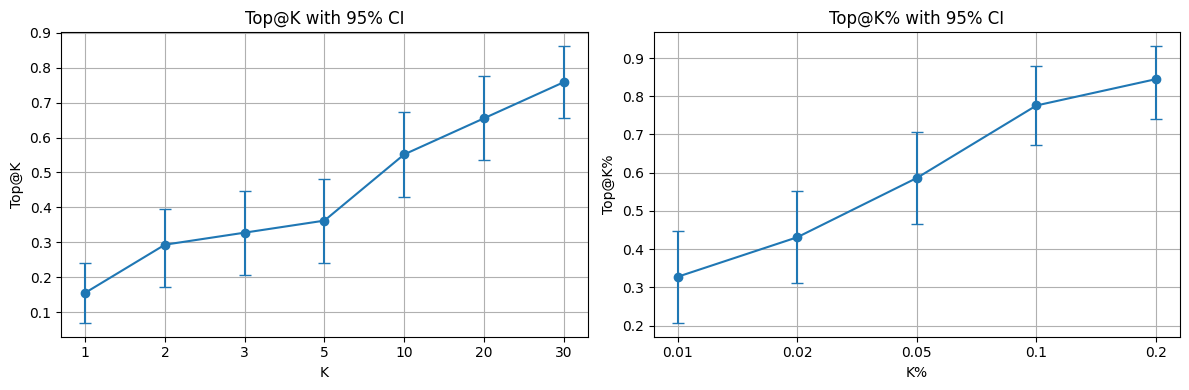

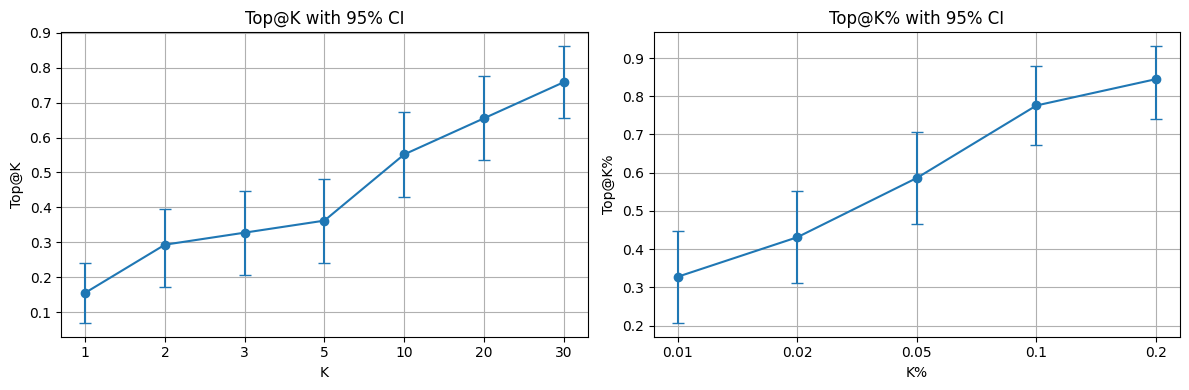

In [37]:
plot_bootstrap_ci(df_topk_ci, df_topkp_ci, save_path="images/significance_bootstrap_ci.png")